In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        '''print(os.path.join(dirname, filename))'''

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import image_dataset_from_directory

In [3]:
train_dir='/kaggle/input/datasets/samuelcortinhas/cats-and-dogs-image-classification/train'
test_dir='/kaggle/input/datasets/samuelcortinhas/cats-and-dogs-image-classification/test'

In [6]:
import tensorflow as tf
from tensorflow.keras import Sequential, layers
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Load training data with validation split
train_data = image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode='binary',
    shuffle=True,
    validation_split=0.2, 
    subset='training',      # This is training portion
    seed=42                 
)

# we are creating our own validation data, if we have already, we can simply use that
val_data = image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode='binary',
    shuffle=True,
    validation_split=0.2,  
    subset='validation',    
    seed=42                 
)

# Load test data
test_data = image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode='binary',
    shuffle=True
)

Found 557 files belonging to 2 classes.
Using 446 files for training.
Found 557 files belonging to 2 classes.
Using 111 files for validation.
Found 140 files belonging to 2 classes.


In [20]:
from tensorflow.keras import Sequential , layers
from tensorflow.keras.regularizers import l1

model = Sequential([
    layers.Conv2D(32, 3, activation='relu', kernel_regularizer=l1(0.001), input_shape=(224, 224, 3)),
    layers.MaxPooling2D(),
    
    layers.Conv2D(64, 3, activation='relu',kernel_regularizer=l1(0.001)),
    layers.MaxPooling2D(),
    
    layers.Conv2D(128, 3, activation='relu',kernel_regularizer=l1(0.001)),
    layers.MaxPooling2D(),
    
    layers.Flatten(),
    
    layers.Dense(512, activation='relu',kernel_regularizer=l1(0.001)),
    layers.Dropout(0.5),
    
    layers.Dense(1, activation='sigmoid')  
])

In [21]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │    44,302,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,396,609 (169.36 MB)

 Trainable params: 44,396,609 (169.36 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history = model.fit(
    train_data,
    epochs=5,
    validation_data=val_data,  
    verbose=1
)

Epoch 1/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.4982 - loss: 382.6840 - val_accuracy: 0.5405 - val_loss: 118.2941
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.6007 - loss: 112.6748 - val_accuracy: 0.4865 - val_loss: 96.8303
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.6738 - loss: 91.7738 - val_accuracy: 0.5315 - val_loss: 78.1772
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.6075 - loss: 74.3908 - val_accuracy: 0.5315 - val_loss: 64.4253
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.7732 - loss: 61.5443 - val_accuracy: 0.5946 - val_loss: 54.7448


In [25]:
import numpy as np

# Evaluate
test_loss, test_accuracy = model.evaluate(test_data)
print(f"\nTest Accuracy with L1 Regularizer: {test_accuracy:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 547ms/step - accuracy: 0.5835 - loss: 54.7048

Test Accuracy with L1 Regularizer: 0.5929


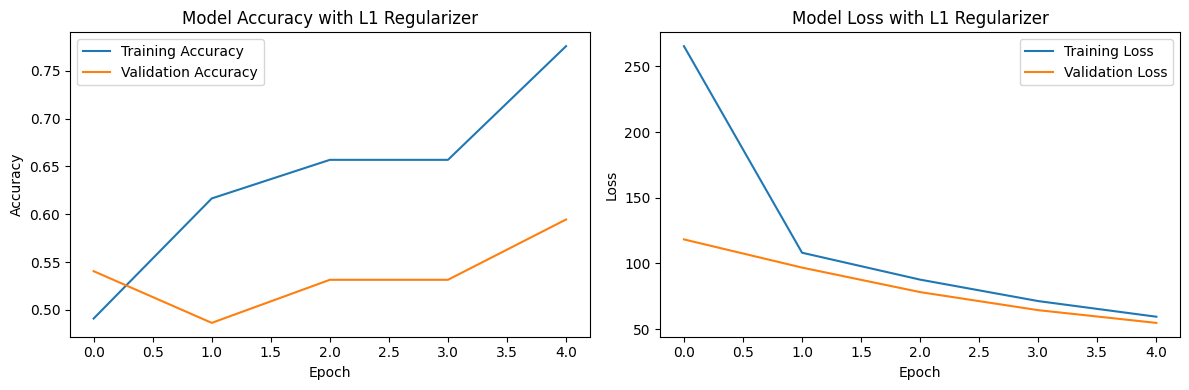

In [26]:
import matplotlib.pyplot as plt

# Then your plotting code
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy with L1 Regularizer')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss with L1 Regularizer')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

L2 Regularizer 

In [27]:
from tensorflow.keras import Sequential , layers
from tensorflow.keras.regularizers import l2

model = Sequential([
    layers.Conv2D(32, 3, activation='relu', kernel_regularizer=l2(0.001), input_shape=(224, 224, 3)),
    layers.MaxPooling2D(),
    
    layers.Conv2D(64, 3, activation='relu',kernel_regularizer=l2(0.001)),
    layers.MaxPooling2D(),
    
    layers.Conv2D(128, 3, activation='relu',kernel_regularizer=l2(0.001)),
    layers.MaxPooling2D(),
    
    layers.Flatten(),
    
    layers.Dense(512, activation='relu',kernel_regularizer=l2(0.001)),
    layers.Dropout(0.5),
    
    layers.Dense(1, activation='sigmoid')  
])

In [28]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 512)            │    44,302,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,396,609 (169.36 MB)

 Trainable params: 44,396,609 (169.36 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history = model.fit(
    train_data,
    epochs=5,
    validation_data=val_data,  
    verbose=1
)

Epoch 1/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.4913 - loss: 190.3426 - val_accuracy: 0.5586 - val_loss: 2.1286
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.6478 - loss: 2.1291 - val_accuracy: 0.5315 - val_loss: 2.2174
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.7918 - loss: 1.9044 - val_accuracy: 0.5766 - val_loss: 2.2666
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.8938 - loss: 1.7476 - val_accuracy: 0.5946 - val_loss: 2.4245
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.9516 - loss: 1.6229 - val_accuracy: 0.6126 - val_loss: 2.7031


In [30]:
import numpy as np

# Evaluate
test_loss, test_accuracy = model.evaluate(test_data)
print(f"\nTest Accuracy with L2 Regularizer: {test_accuracy:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 558ms/step - accuracy: 0.5540 - loss: 2.3855

Test Accuracy with L2 Regularizer: 0.5786


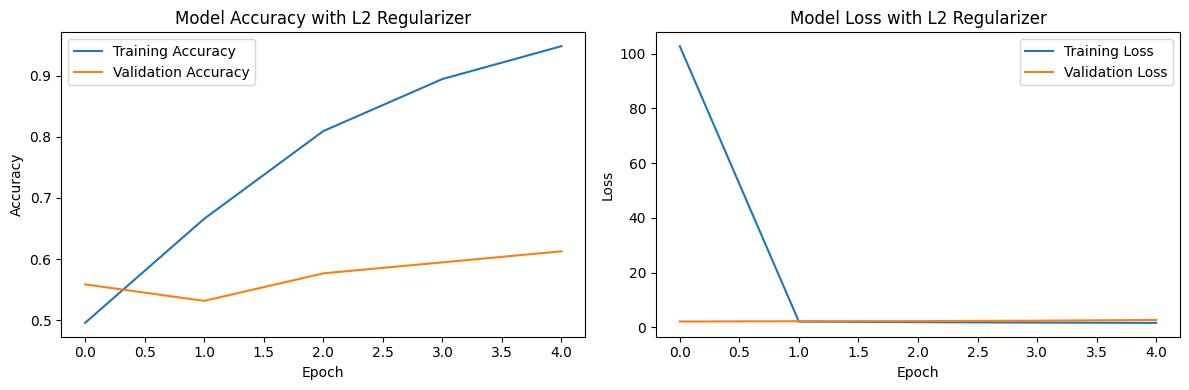

In [31]:
import matplotlib.pyplot as plt

# Then your plotting code
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy with L2 Regularizer')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss with L2 Regularizer')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

L2 Regularizer is working better than L1 Regularizer 